<a href="https://colab.research.google.com/github/shahabzaman718-cmyk/Final-year-project-/blob/main/Physics_Signal_Classifier_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Physics Signal Classification: Separating Gamma Rays from Hadronic Backgrounds in Telescope Data.**

# **Loading Dataset and Environment Setup**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature names from documentation
column_names = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym",
    "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"
]

# Load the dataset
df = pd.read_csv('magic04.data', names=column_names)



# **Exploratory Data Analysis**

## **1. Data Inspection & Missingness Check**
In this we will inspect the basic dataset and then check the missing values in the dataset

In [13]:
# Basic Inspection
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Missing Values Summary:
          Missing Values  Percentage (%)
fLength                0             0.0
fWidth                 0             0.0
fSize                  0             0.0
fConc                  0             0.0
fConc1                 0             0.0
fAsym                  0             0.0
fM3Long                0             0.0
fM3Trans               0             0.0
fAlpha                 0             0.0
fDist                  0             0.0
class                  0             0.0


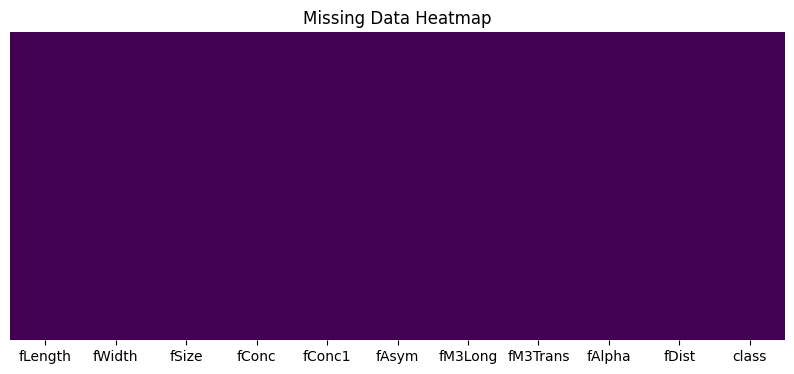

In [14]:
# 1. Numerical Summary of Missing Values
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

print("Missing Values Summary:")
print(missing_df)

# 2. Visualizing Missing Data
# Even if there are no missing values, a heatmap confirms the data integrity.
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

## **2. Class Distribution Analysis**
Understanding the balance between Gamma ('g') and Hadron ('h') events is crucial for choosing the right evaluation metrics (like ROC-AUC).

/tmp/ipykernel_2065/3087864390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


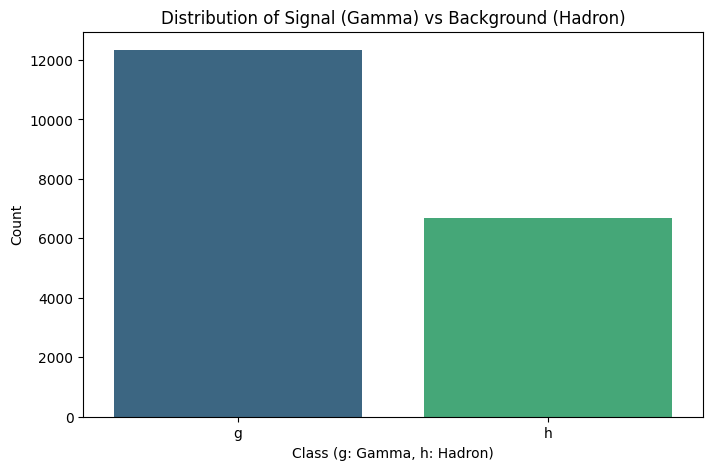

Class counts:
 class
g    0.64837
h    0.35163
Name: proportion, dtype: float64


In [15]:
# Check for class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Signal (Gamma) vs Background (Hadron)')
plt.xlabel('Class (g: Gamma, h: Hadron)')
plt.ylabel('Count')
plt.show()

print("Class counts:\n", df['class'].value_counts(normalize=True))

## **3. Univariate Analysis (Feature Distributions)**
We examine the distribution of each individual numerical feature to understand their range and skewness.

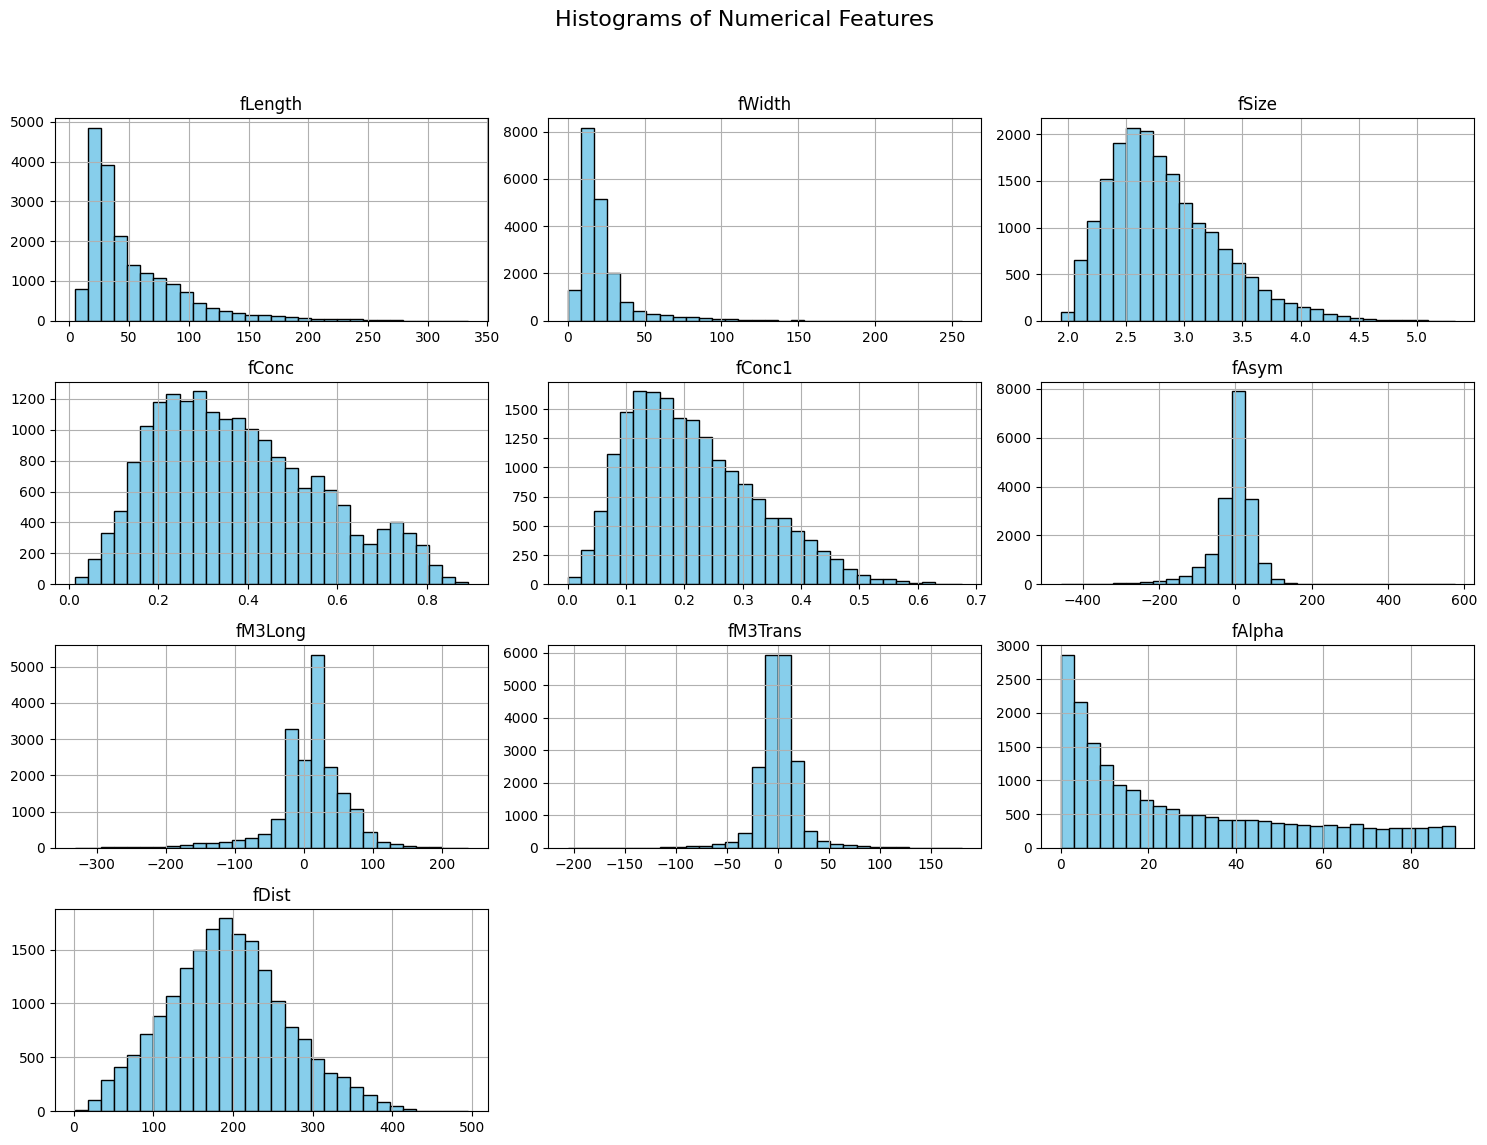

In [16]:
# Histograms for all numerical features
df.drop('class', axis=1).hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **4. Bivariate Analysis: Signal vs. Background**
This is the most critical part of the EDA for physics classification. We use Kernel Density Estimation (KDE) plots to see how well features separate the two classes.

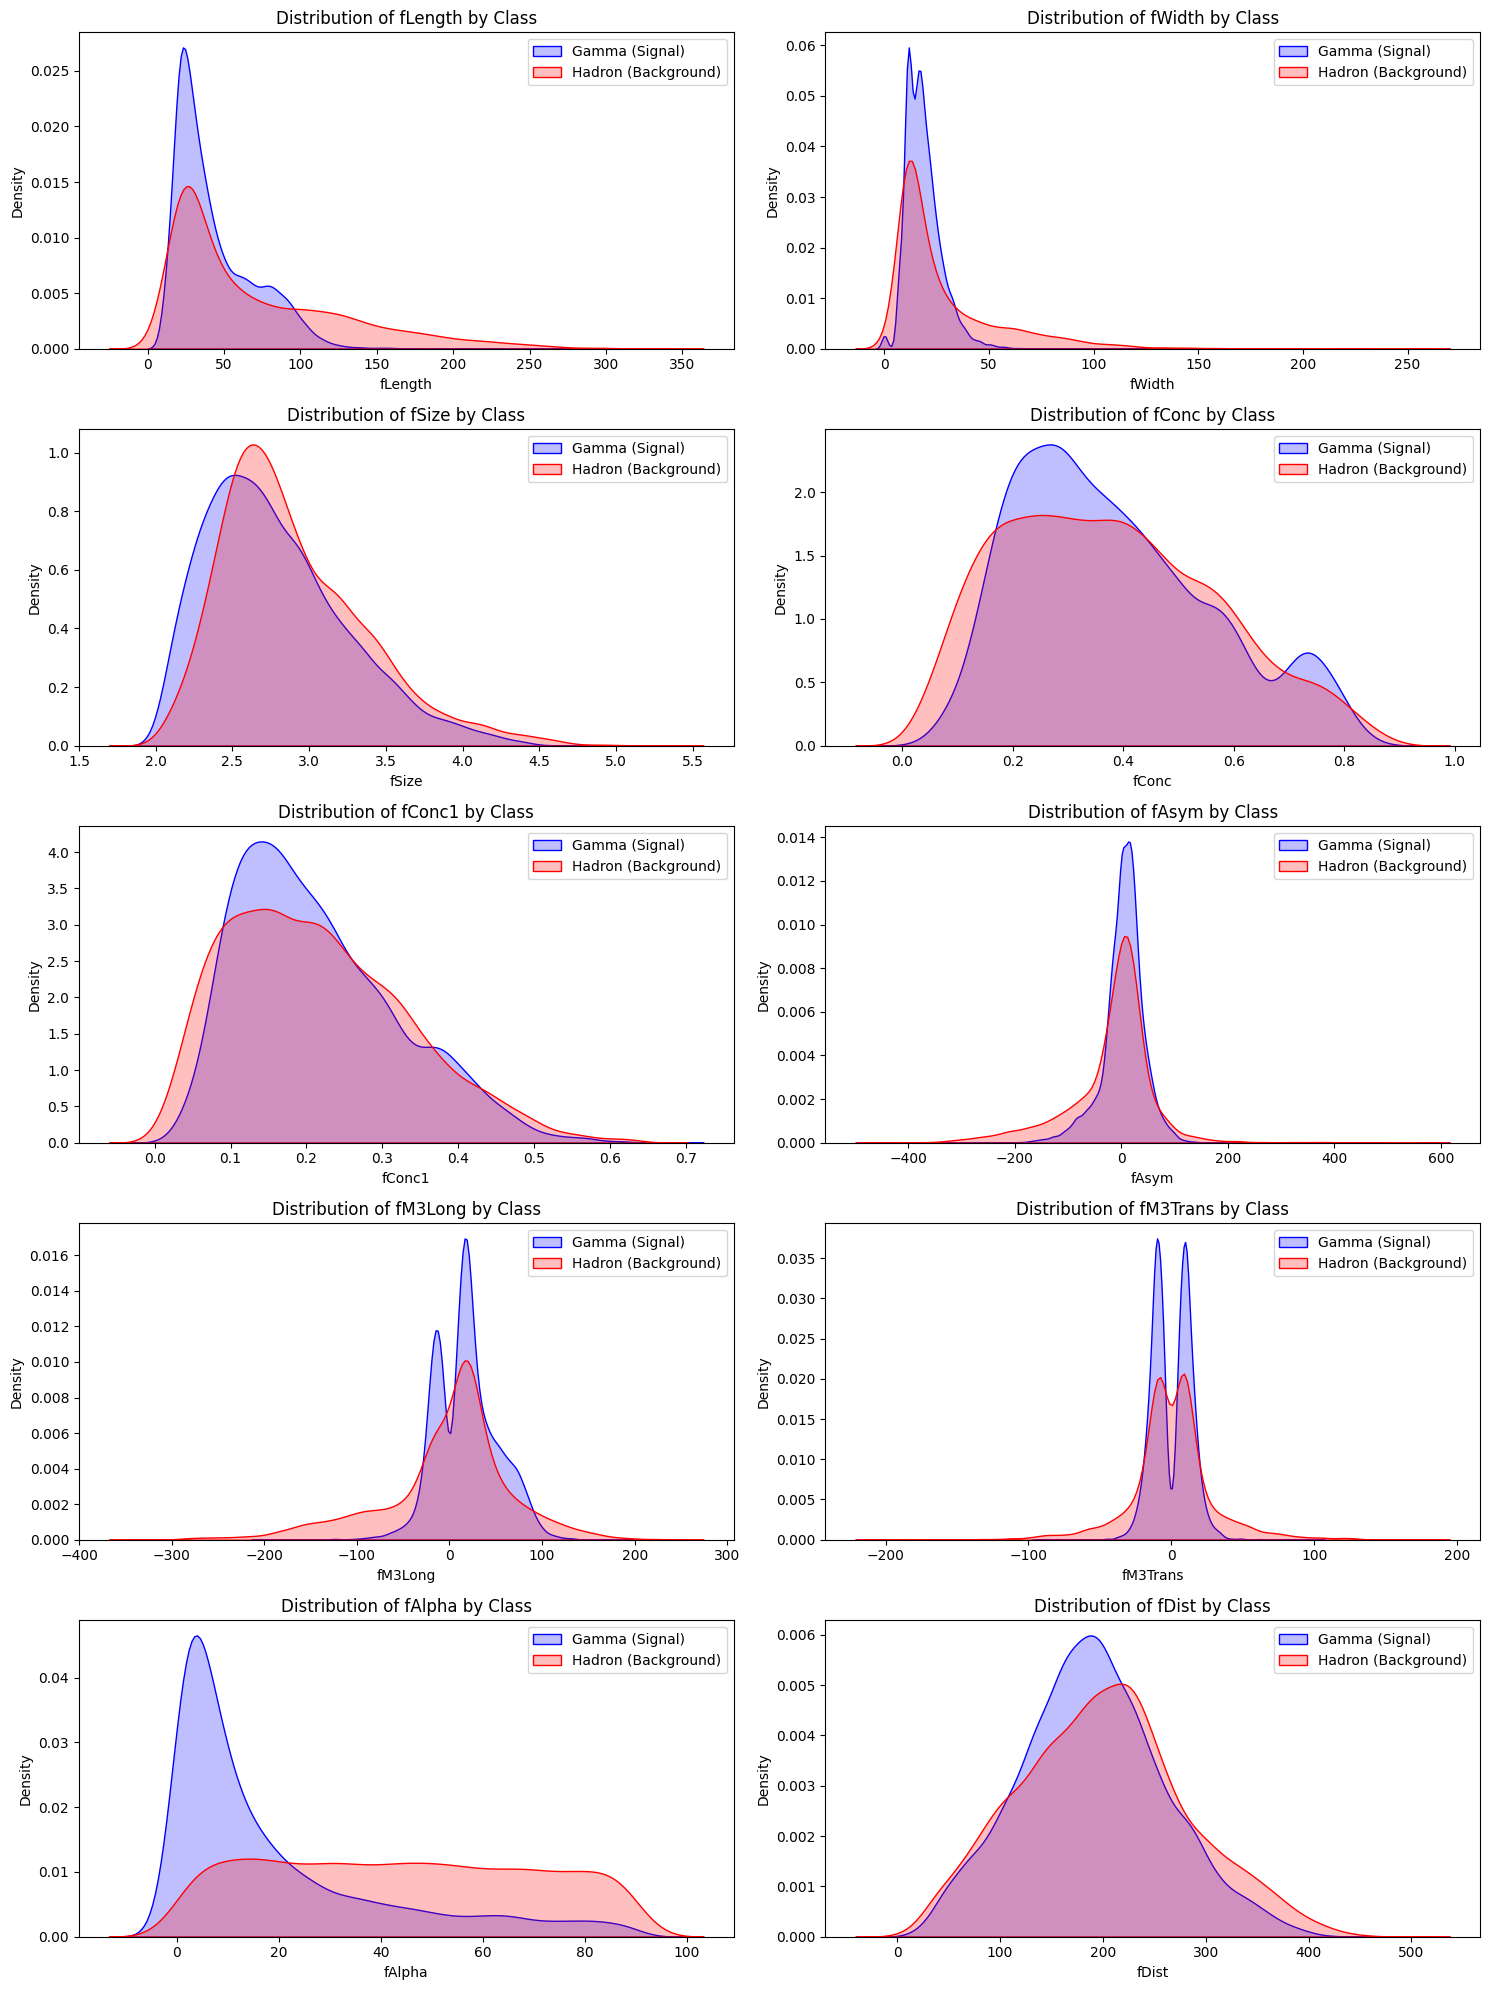

In [17]:
features = df.columns[:-1]
plt.figure(figsize=(15, 20))

for i, col in enumerate(features):
    plt.subplot(5, 2, i + 1)
    sns.kdeplot(df[df['class'] == 'g'][col], label='Gamma (Signal)', fill=True, color='blue')
    sns.kdeplot(df[df['class'] == 'h'][col], label='Hadron (Background)', fill=True, color='red')
    plt.title(f'Distribution of {col} by Class')
    plt.legend()

plt.tight_layout()
plt.show()

## **5. Correlation Analysis**
We look for multicollinearity between features and their relationship with the target variable.

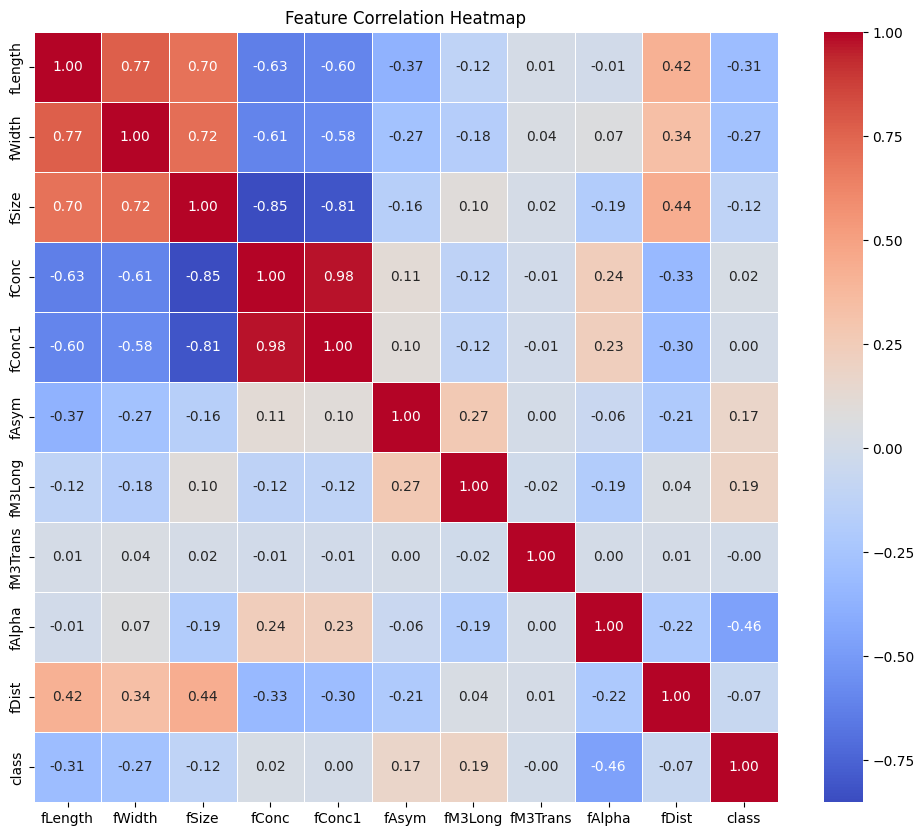

In [18]:
# Map class to numeric for correlation (g=1, h=0)
df_numeric = df.copy()
df_numeric['class'] = df_numeric['class'].map({'g': 1, 'h': 0})

plt.figure(figsize=(12, 10))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## **6. Outlier Detection**
Standardizing the data might be necessary as some features contain significant outliers.

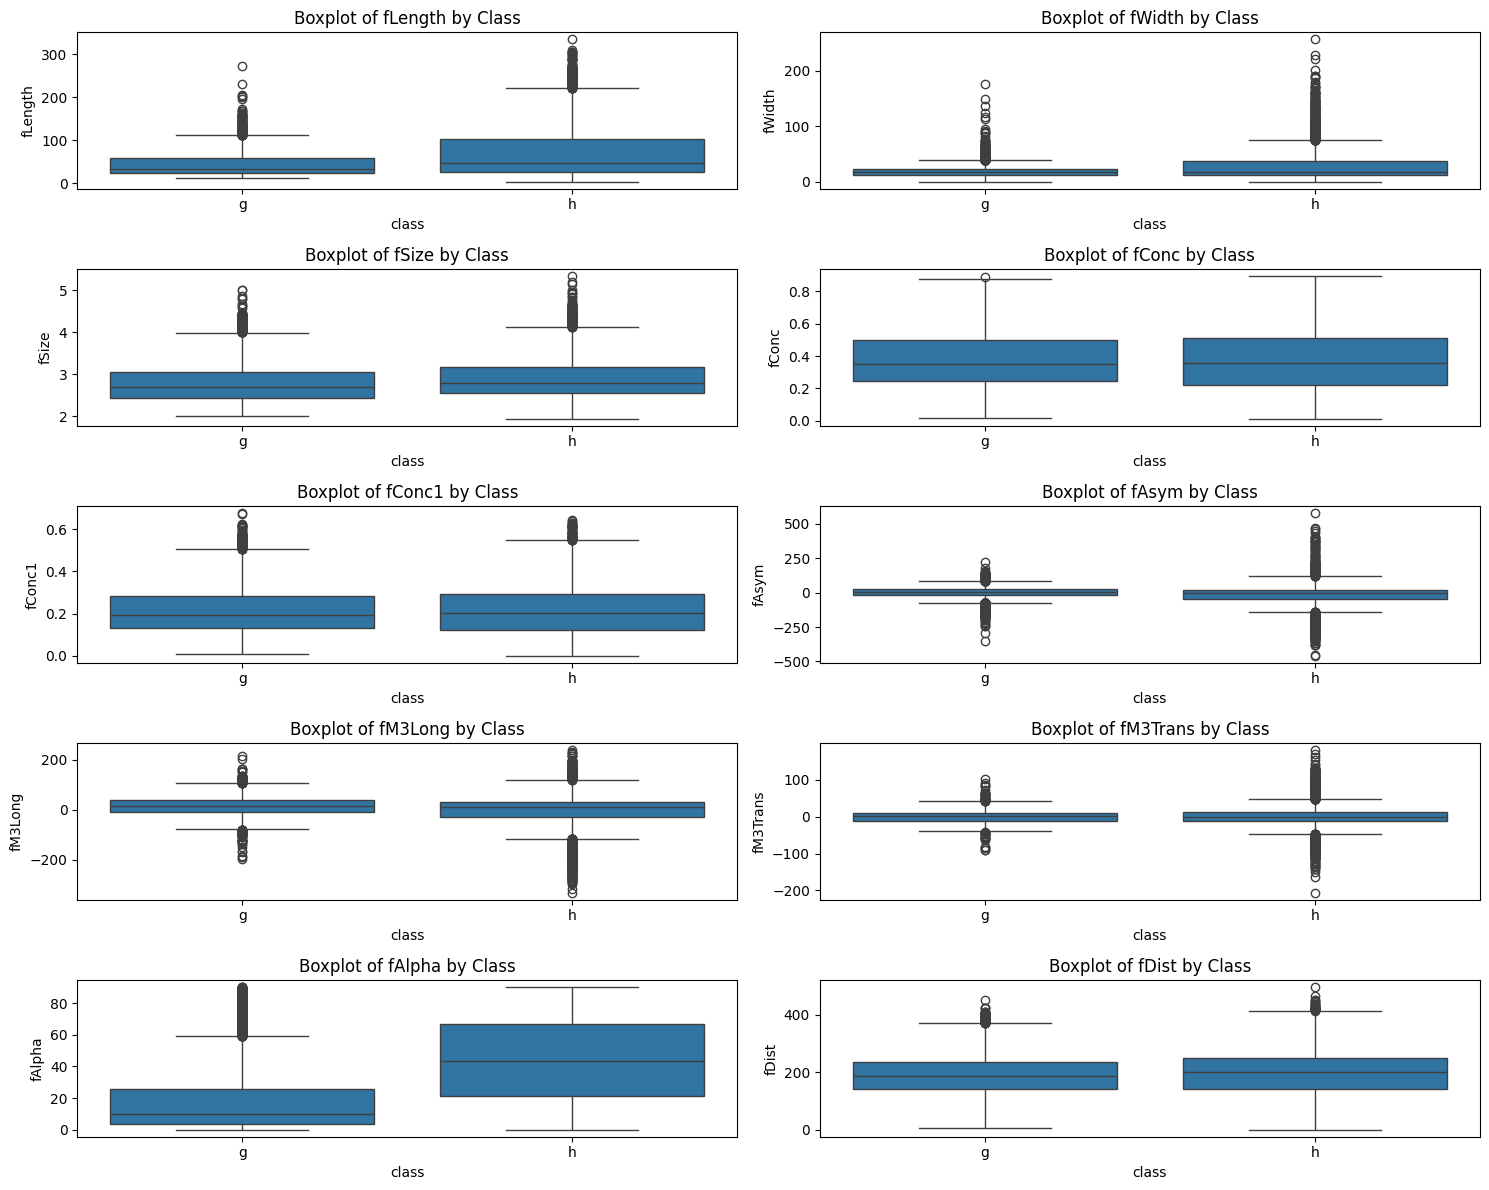

In [19]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(features):
    plt.subplot(5, 2, i + 1)
    sns.boxplot(x='class', y=col, data=df)
    plt.title(f'Boxplot of {col} by Class')

plt.tight_layout()
plt.show()

# **Preprocessing**

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load your data (assuming df is already loaded)
# df = pd.read_csv('magic_gamma_telescope.csv')

# 1. Encode labels: g -> 1, h -> 0
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# 2. Separate features and target
X = df.drop('class', axis=1).values
y = df['class'].values

# 3. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# **Model Training**

## **Helper Function**

In [21]:
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)
import matplotlib.pyplot as plt

def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    print(f"\n{'='*20} {name} {'='*20}")

    # Timing Training
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Timing Prediction
    start_pred = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_pred

    # Metrics
    print(f"Train Time: {train_time:.4f}s | Test Time: {test_time:.4f}s")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title(f"Confusion Matrix: {name}")

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else: # For SVM linear if probability=False
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f"ROC Curve: {name}")
    ax[1].legend()
    plt.show()

    return fpr, tpr, auc(fpr, tpr)

## **Defining & Trianing Model**


==================== KNN (Distance-Based) ====================
Train Time: 0.0174s | Test Time: 0.1968s
Accuracy:  0.8346
Precision: 0.8415
Recall:    0.6555
F1-Score:  0.7369

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      2460
           1       0.84      0.66      0.74      1344

    accuracy                           0.83      3804
   macro avg       0.84      0.79      0.81      3804
weighted avg       0.84      0.83      0.83      3804



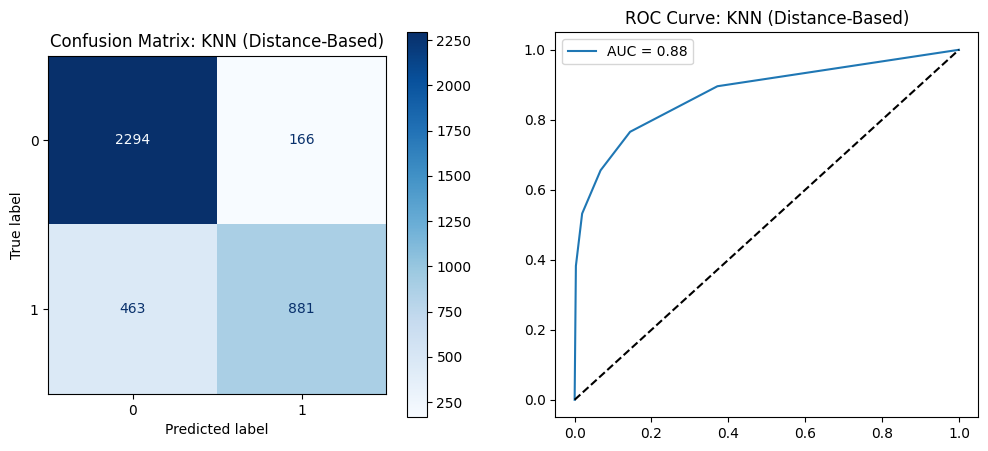


==================== Logistic Regression (Boundary-Based) ====================
Train Time: 0.0362s | Test Time: 0.0004s
Accuracy:  0.7931
Precision: 0.7610
Recall:    0.6042
F1-Score:  0.6736

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2460
           1       0.76      0.60      0.67      1344

    accuracy                           0.79      3804
   macro avg       0.78      0.75      0.76      3804
weighted avg       0.79      0.79      0.79      3804



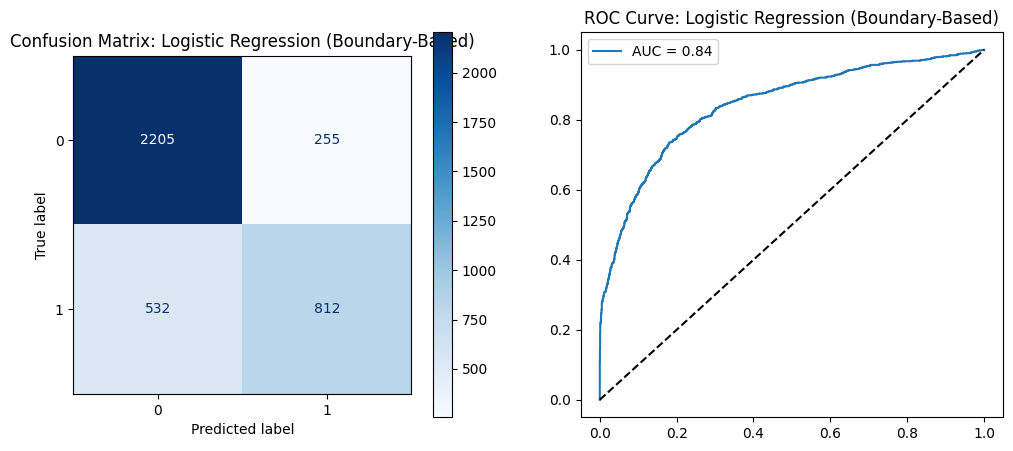


==================== SVM (Boundary-Based) ====================
Train Time: 37.6010s | Test Time: 0.4755s
Accuracy:  0.7936
Precision: 0.7567
Recall:    0.6131
F1-Score:  0.6774

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      2460
           1       0.76      0.61      0.68      1344

    accuracy                           0.79      3804
   macro avg       0.78      0.75      0.76      3804
weighted avg       0.79      0.79      0.79      3804



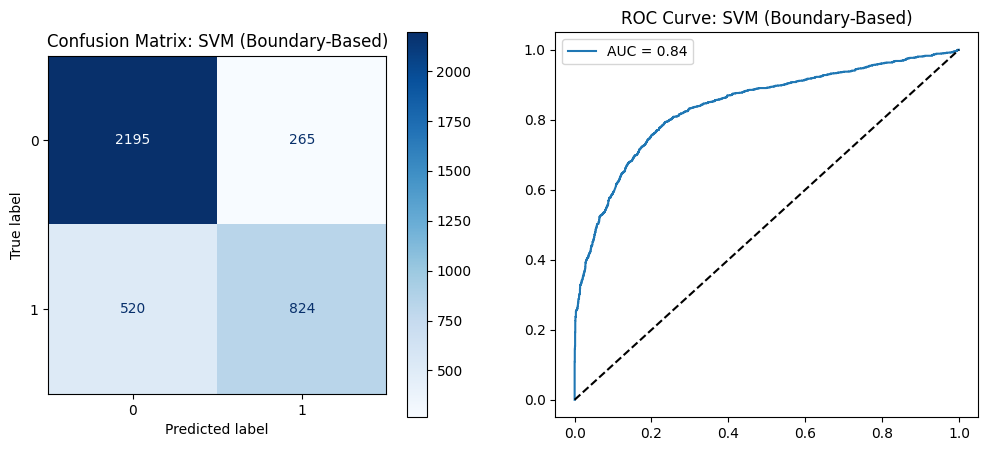

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. K-Nearest Neighbors
k_nearest_neighbors_classifier_results = evaluate_model(KNeighborsClassifier(n_neighbors=5),
                             "KNN (Distance-Based)", X_train, X_test, y_train, y_test)
# hibmsd
# 2. Logistic Regression
log_results = evaluate_model(LogisticRegression(),
                             "Logistic Regression (Boundary-Based)", X_train, X_test, y_train, y_test)
# 2nd chnage
# 3. Support Vector Machine
# Note: probability=True allows for predict_proba used in ROC
svm_results = evaluate_model(SVC(kernel='linear', probability=True),
                             "SVM (Boundary-Based)", X_train, X_test, y_train, y_test)